<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 27.7 MB/s eta 0:00:00


In [3]:
from fastai.vision.all import *
import timm

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

### Resnet 50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=128)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='modelResnet50')  
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.004365158267319202)

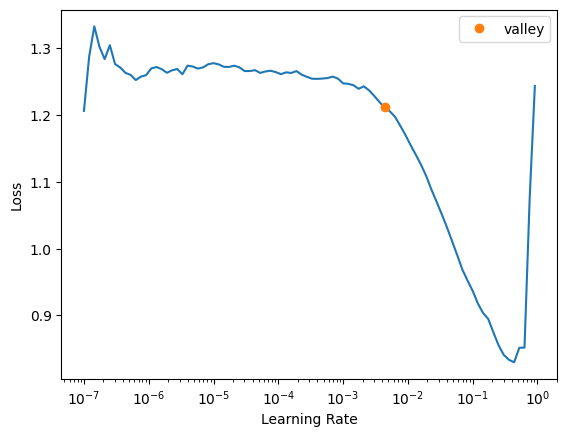

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.134718,0.111616,0.977699,0.000000,0.000000,0.000000,08:48


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11161649227142334.


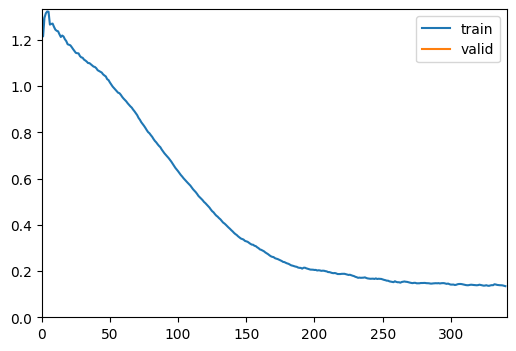

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.105737,0.135013,0.977699,0.000000,0.000000,0.000000,09:04
1,0.113950,0.282286,0.977699,0.000000,0.000000,0.000000,09:04
2,0.112792,0.106755,0.977699,0.000000,0.000000,0.000000,09:10
3,0.099973,0.108033,0.977699,0.000000,0.000000,0.000000,09:09
4,0.098181,0.109675,0.977699,0.000000,0.000000,0.000000,09:02
5,0.098691,0.103121,0.977699,0.000000,0.000000,0.000000,08:51
6,0.096698,0.097624,0.977699,0.500000,0.004098,0.008130,08:40
7,0.089409,0.101533,0.977424,0.440000,0.045082,0.081784,08:49
8,0.088965,0.099235,0.977333,0.437500,0.057377,0.101449,09:03
9,0.088852,0.097297,0.977699,0.500000,0.036885,0.068702,08:59


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1350134015083313.


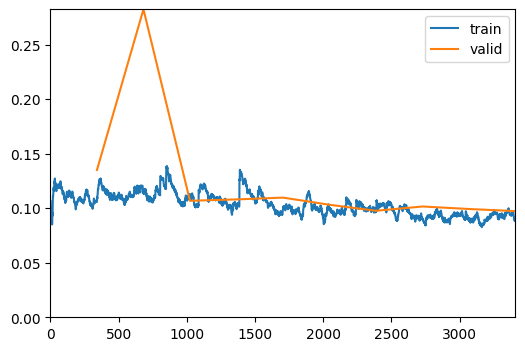

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.10675548017024994.


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.10312093794345856.
Better model found at epoch 6 with valid_loss value: 0.09762357920408249.
Better model found at epoch 9 with valid_loss value: 0.09729737788438797.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 40 mins.

### EfficientNet

Para que la ejecució quepa en la caché, hay que reducir los tamaños de las imágenes y el batch.

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='efficientNetB3')  
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 130MB/s]


In [ ]:
import torch
torch.cuda.empty_cache()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.157429,0.123083,0.979527,0.000000,0.000000,0.000000,09:34


Better model found at epoch 0 with valid_loss value: 0.12308338284492493.


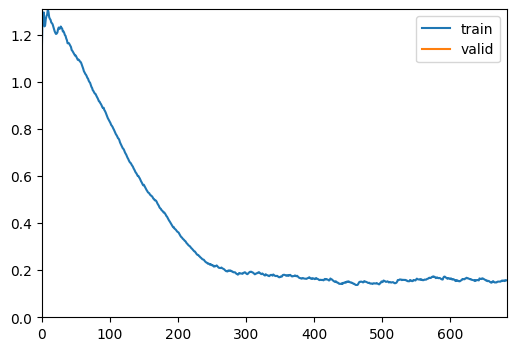

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.109194,0.098137,0.980441,0.000000,0.000000,0.000000,09:29
1,0.114298,0.099628,0.980441,0.000000,0.000000,0.000000,09:19
2,0.125833,0.099406,0.980441,0.000000,0.000000,0.000000,09:17
3,0.109041,0.095146,0.980441,0.000000,0.000000,0.000000,09:16
4,0.103849,0.098076,0.980441,0.000000,0.000000,0.000000,09:19
5,0.088844,0.095915,0.980441,0.000000,0.000000,0.000000,09:19
6,0.107047,nan,0.980441,0.000000,0.000000,0.000000,09:19
7,0.106938,nan,0.980441,0.000000,0.000000,0.000000,09:28
8,0.091529,0.092460,0.980441,0.000000,0.000000,0.000000,09:36
9,0.101932,0.092285,0.980441,0.000000,0.000000,0.000000,09:33


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09813690185546875.


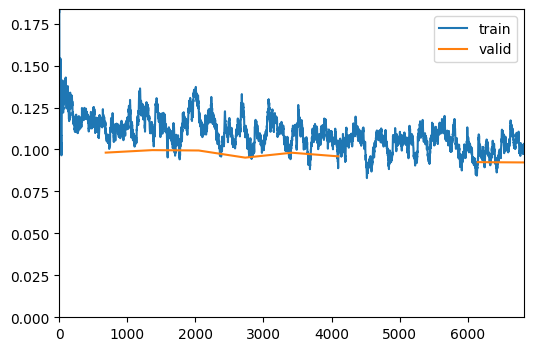

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09514576196670532.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Better model found at epoch 8 with valid_loss value: 0.09245970100164413.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 9 with valid_loss value: 0.09228470921516418.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 44 mins.

### ConvNext

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='ConvNext')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:07<00:00, 45.9MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.154840,0.114093,0.980258,0.000000,0.000000,0.000000,09:11


Better model found at epoch 0 with valid_loss value: 0.11409283429384232.


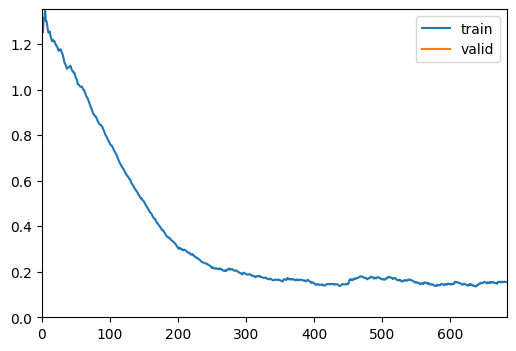

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.097386,0.097244,0.980441,0.000000,0.000000,0.000000,09:37
1,0.124461,0.116928,0.980441,0.000000,0.000000,0.000000,09:37
2,0.101866,0.100506,0.980441,0.000000,0.000000,0.000000,09:35
3,0.108117,0.091792,0.980441,0.000000,0.000000,0.000000,09:36
4,0.100571,0.094839,0.980441,0.000000,0.000000,0.000000,09:36
5,0.107470,0.090112,0.980441,0.000000,0.000000,0.000000,09:37
6,0.107873,0.088212,0.980898,0.857143,0.028037,0.054299,09:39
7,0.106709,0.086807,0.980532,0.538462,0.032710,0.061674,09:30
8,0.096510,0.085968,0.980898,0.857143,0.028037,0.054299,09:29
9,0.099173,0.086072,0.980623,0.600000,0.028037,0.053571,09:28


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09724444150924683.


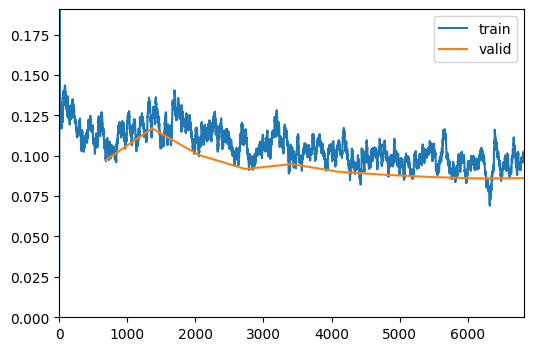

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09179195761680603.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.09011197090148926.
Better model found at epoch 6 with valid_loss value: 0.08821216225624084.
Better model found at epoch 7 with valid_loss value: 0.08680716902017593.
Better model found at epoch 8 with valid_loss value: 0.08596846461296082.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 45 mins.

### Hrnet

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Hrnet')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=32)

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-hrnet/hrnetv2_w44-c9ac8c18.pth" to /root/.cache/torch/hub/checkpoints/hrnetv2_w44-c9ac8c18.pth


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.144876,0.131406,0.976236,0.000000,0.000000,0.000000,12:44


Better model found at epoch 0 with valid_loss value: 0.13140591979026794.


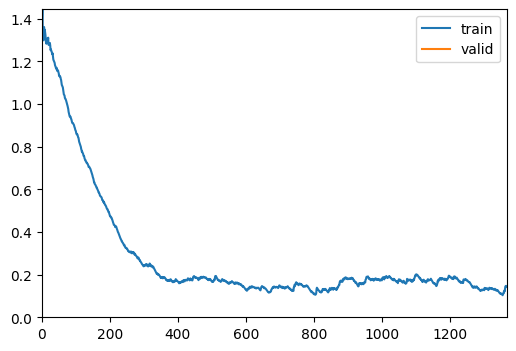

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.099613,0.123273,0.976328,0.000000,0.000000,0.000000,14:00
1,0.126929,0.126066,0.976328,0.000000,0.000000,0.000000,14:00
2,0.118984,0.112464,0.976328,0.000000,0.000000,0.000000,14:10
3,0.114417,0.116200,0.976328,0.000000,0.000000,0.000000,13:59
4,0.103200,0.240522,0.974043,0.000000,0.000000,0.000000,13:58
5,0.095524,1.490318,0.974500,0.000000,0.000000,0.000000,13:55
6,0.101700,nan,0.976328,0.000000,0.000000,0.000000,13:54
7,0.073411,nan,0.976510,0.625000,0.019305,0.037453,13:52
8,0.094232,0.105128,0.976419,0.555556,0.019305,0.037313,13:52
9,0.097534,nan,0.976510,0.625000,0.019305,0.037453,13:50


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.12327256053686142.


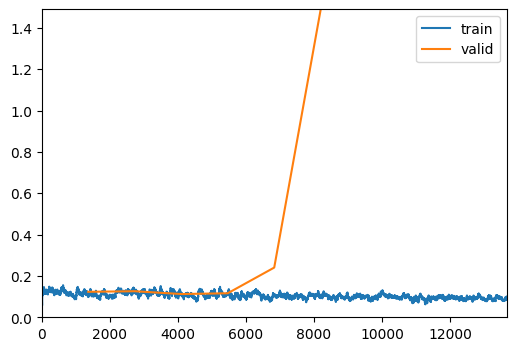

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.11246427148580551.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 8 with valid_loss value: 0.10512750595808029.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

2 horas 33 minutos.

### Deit

In [6]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')  
]

In [15]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(384), # Solo funciona con este tamaño
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [25]:
dls = db.dataloaders(imagesPath, bs=8)

In [26]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h solo en la primera época, por lo que se espera que tarde 10 horas.